# Experimento A/B en página de inicio

El objetivo de este proyecto es evaluar un experimento A/B realizado en una página de inicio (landing page) con versiones A y B, con el propósito de determinar si existen diferencias relevantes en el comportamiento de los usuarios y en el desempeño económico de ambas versiones.

El archivo `landing_experiment.csv` contiene información de usuarios expuestos a las dos versiones de la página. El dataset incluye variables como región, dispositivo, fuente de tráfico, tipo de usuario, conversión y gasto.

El análisis se centra en evaluar el desempeño de ambas versiones mediante métricas de conversión y gasto, así como en explorar posibles diferencias según la fuente de tráfico y el tipo de usuario.

Los resultados se interpretan desde una perspectiva de negocio, buscando identificar diferencias estadísticamente significativas y oportunidades para optimizar la estrategia de marketing y el diseño de la página de inicio.

## Carga y validación de datos

### Carga de datos y vista rápida

In [1]:
# Importación de librerías
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt

from scipy.stats import ttest_ind
from scipy.stats import levene
from statsmodels.stats.proportion import proportions_ztest
from scipy.stats import chi2_contingency

In [2]:
# Carga de archivo
df = pd.read_csv('/datasets/landing_experiment.csv')

**Vista previa e información general del conjunto de datos**

In [3]:
# Se muestran las primeras 5 filas
df.head()

,user_id,date,landing,region,dispositivo,traffic_source,user_type,converted,gasto
0,26f3052e-8500-44ea-8fff-06de65258abb,2026-01-01,A,Norte,Mobile,Email,Recurrente,1,38.08
1,92378c09-4bbf-40c7-945e-82b84f392d22,2026-01-23,A,Occidente,Mobile,Organic,Nuevo,0,0.00
2,a4397360-40e5-45d6-a7ff-dcb4da2c9a1f,2026-01-01,B,Centro,Mobile,Organic,Nuevo,0,0.00
3,7ca3a26f-1e6c-44aa-9b09-b8cb01112956,2026-01-22,A,Centro,Mobile,Ads,Nuevo,0,0.00
4,8dc9593b-5b9c-479d-848b-a99493920419,2026-01-16,A,Sur,Mobile,Organic,Nuevo,0,0.00


In [4]:
# Información general
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   user_id         40000 non-null  object 
 1   date            40000 non-null  object 
 2   landing         40000 non-null  object 
 3   region          40000 non-null  object 
 4   dispositivo     40000 non-null  object 
 5   traffic_source  40000 non-null  object 
 6   user_type       40000 non-null  object 
 7   converted       40000 non-null  int64  
 8   gasto           40000 non-null  float64
dtypes: float64(1), int64(1), object(7)
memory usage: 2.7+ MB


- No se identificaron valores ausentes en el dataset.
- La columna `date` es de tipo de dato `object`, y debería ser `datetime` al representar una fecha. Se realiza la conversión.

In [5]:
# Se convierte la columna de fecha al tipo datetime
df["date"] = pd.to_datetime(df["date"], errors="coerce")

# Verificación de cambio en formato
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   user_id         40000 non-null  object        
 1   date            40000 non-null  datetime64[ns]
 2   landing         40000 non-null  object        
 3   region          40000 non-null  object        
 4   dispositivo     40000 non-null  object        
 5   traffic_source  40000 non-null  object        
 6   user_type       40000 non-null  object        
 7   converted       40000 non-null  int64         
 8   gasto           40000 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(1), object(6)
memory usage: 2.7+ MB


### Análisis exploratorio y revisión de calidad de datos

Se identifican las variables clave del experimento A/B y se valida que estén correctamente definidas, completas y sean consistentes.

 **Variable `user_id`**  
Se verifica la unicidad de los identificadores de usuario.

In [6]:
# Verificación
df["user_id"].duplicated().sum()

0

 **Variable `date`**  
Se revisa el rango temporal del experimento.

In [7]:
# Resumen estadístico
df["date"].describe()

count                   40000
unique                     28
top       2026-01-24 00:00:00
freq                     1512
first     2026-01-01 00:00:00
last      2026-01-28 00:00:00
Name: date, dtype: object

In [8]:
# Rango temporal del experimento
print("Fecha mínima:", df["date"].min())
print("Fecha máxima:", df["date"].max())

Fecha mínima: 2026-01-01 00:00:00
Fecha máxima: 2026-01-28 00:00:00


**Variable `gasto`**

In [9]:
# Resumen estadístico
df["gasto"].describe()

count    40000.000000
mean         9.325554
std         25.667986
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max        303.680000
Name: gasto, dtype: float64

In [10]:
# Resumen estadístico de usuarios que se convirtieron
df.loc[df["converted"] == 1, "gasto"].describe()

count    5706.000000
mean       65.373668
std        30.896545
min        12.120000
25%        42.950000
50%        59.860000
75%        80.370000
max       303.680000
Name: gasto, dtype: float64

 **Variables categóricas**  
 Se revisa la distribución de las categorías presentes en las variables del experimento.

In [11]:
# Explorar variables categóricas y cómo se distribuyen
print("Conteo de categorías:")
for col in ["landing", "region", "dispositivo", "traffic_source", "user_type", "converted"]:
    print(f"\nColumna {col}")
    print(df[col].value_counts(dropna=False))

Conteo de categorías:

Columna landing
B    20018
A    19982
Name: landing, dtype: int64

Columna region
Norte        11166
Centro        9613
Sur           8039
Occidente     6398
Oriente       4784
Name: region, dtype: int64

Columna dispositivo
Mobile     24829
Desktop    15171
Name: dispositivo, dtype: int64

Columna traffic_source
Organic     17987
Ads         11935
Email        6123
Referral     3955
Name: traffic_source, dtype: int64

Columna user_type
Nuevo         26033
Recurrente    13967
Name: user_type, dtype: int64

Columna converted
0    34294
1     5706
Name: converted, dtype: int64


- Se verificaron las variables categóricas y todas presentan las categorías esperadas.
- No se identificaron categorías mal escritas, valores inesperados ni inconsistencias en los datos.

## Comparación del gasto promedio

El análisis compara el gasto promedio de los usuarios que realizaron una conversión entre las versiones A y B de la landing page.

In [12]:
# Gasto por versión
gasto_A = df[(df["landing"] == "A") & (df["converted"] == 1)]["gasto"]
gasto_B = df[(df["landing"] == "B") & (df["converted"] == 1)]["gasto"]

# Tamaño de cada grupo
len(gasto_A), len(gasto_B)

(2512, 3194)

In [13]:
# Gasto promedio por versión
print(f"Gasto promedio - Página A: {gasto_A.mean():.2f}")
print(f"Gasto promedio - Página B: {gasto_B.mean():.2f}")

Gasto promedio - Página A: 61.09
Gasto promedio - Página B: 68.75


FileNotFoundError: [Errno 2] No such file or directory: 'images/avg_spend_ab.png'

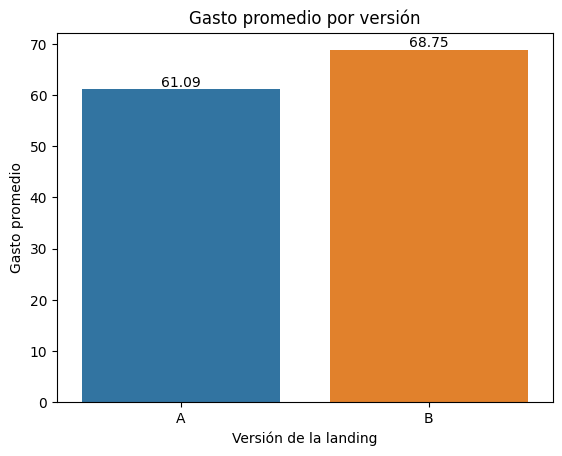

In [14]:
# Gráfico de gasto promedio por versión
promedios = {
    "A": gasto_A.mean(),
    "B": gasto_B.mean()
}
ax = sns.barplot(
    x=list(promedios.keys()),
    y=list(promedios.values())
)
for bar in ax.patches:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:.2f}",
        ha="center",
        va="bottom"
    )
plt.title("Gasto promedio por versión")
plt.xlabel("Versión de la landing")
plt.ylabel("Gasto promedio")
plt.savefig("images/avg_spend_ab.png", dpi=300, bbox_inches="tight")
plt.show()

### Verificación de supuestos

Antes de aplicar la prueba para comparar las medias entre ambas versiones, se evalúa la igualdad de varianzas mediante la prueba de Levene.

- **H₀:** las varianzas del gasto son iguales entre las versiones A y B.
- **H₁:** las varianzas del gasto son diferentes entre las versiones A y B.

Para esta y las demás pruebas estadísticas, se utilizará un **nivel de significancia de 0.05**.

In [ ]:
# Prueba de Levene
l_stat, p_value_var = levene(gasto_A, gasto_B)

# Umbral de significancia
alpha = 0.05  

# Resultados
print(f"Estadístico: {l_stat:.3f}")
print(f"Valor p: {p_value_var:.3g}")

El resultado de la prueba de Levene permite **rechazar H₀**, indicando evidencia de diferencias en la varianza del gasto entre ambas versiones. Por ello, se utilizará la prueba t de Welch para comparar las medias de ambos grupos.

### Prueba t de Welch

Se evalúa si la diferencia observada en el gasto promedio entre las versiones A y B es estadísticamente significativa.

- **H₀:** El gasto promedio de los usuarios convertidos es igual entre las páginas A y B.
- **H₁:** El gasto promedio de los usuarios convertidos es diferente entre las páginas A y B.

In [ ]:
# Prueba t de Welch
t_stat, p_value = ttest_ind(gasto_A, gasto_B, equal_var=False)

# Umbral de significancia
alpha = 0.05

# Resultados
print(f"Estadístico: {t_stat:.3f}")
print(f"Valor p: {p_value:.3g}")

### Conclusión e interpretación

**Resultado estadístico**

Se rechaza la hipótesis nula (H₀), ya que el valor p es inferior al nivel de significancia de 0.05. Existe evidencia estadísticamente significativa de una diferencia en el gasto promedio de los usuarios convertidos entre las páginas A y B.

**Interpretación de negocio**

La página B presentó un gasto promedio superior al de la página A (68.75 frente a 61.09 unidades monetarias). La diferencia observada es estadísticamente significativa, lo que indica que es poco probable que se deba únicamente al azar dentro de los datos analizados.

En términos de valor económico por usuario convertido, la versión B presentó un mayor gasto promedio durante el período del experimento.

## Comparación de la tasa de conversión

El análisis compara la tasa de conversión entre las versiones A y B de la landing page, para identificar diferencias en el porcentaje de usuarios que realizaron una conversión.

In [ ]:
# Total de usuarios por página
totales = df.groupby("landing")["converted"].count()

# Usuarios convertidos por página
conversiones = df.groupby("landing")["converted"].sum()

# Preparar datos para el cálculo de tasas 
totales_list = [totales["A"], totales["B"]]
conversiones_list = [conversiones["A"], conversiones["B"]]

print("\nUsuarios totales:\n", totales)
print("\nUsuarios convertidos:\n", conversiones)

In [ ]:
# Tasa de conversión por versión

tasa_A = conversiones_list[0] / totales_list[0]
tasa_B = conversiones_list[1] / totales_list[1]
diferencia_pp = (tasa_B - tasa_A) * 100

print(f"Tasa de conversión de página A: {tasa_A:.2%}")
print(f"Tasa de conversión de página B: {tasa_B:.2%}")
print(f"Diferencia: {diferencia_pp:.2f} puntos porcentuales")

In [ ]:
# Gráfico de tasa de conversión por versión
plt.figure(figsize=(8,5))
versiones = ["A", "B"]
tasas = [tasa_A * 100, tasa_B * 100]
barras = plt.bar(
    versiones,
    tasas,
    color=["#377BA8", "#E77E26"]
)
for barra in barras:
    altura = barra.get_height()
    plt.text(
        barra.get_x() + barra.get_width() / 2,
        altura,
        f"{altura:.2f}%",
        ha="center",
        va="bottom"
    )
plt.title("Tasa de conversión por versión", fontsize=15)
plt.xlabel("Versión de la landing", fontsize=12)
plt.ylabel("Tasa de conversión (%)", fontsize=12)
plt.savefig("images/conversion_rate_ab.png", dpi=300, bbox_inches="tight")
plt.show()

### Prueba z de Proporciones

Se evalúa si la diferencia observada en las tasas de conversión entre las versiones A y B es estadísticamente significativa.

- **H₀:** La tasa de conversión es igual entre las páginas A y B.
- **H₁:** La tasa de conversión es diferente entre las páginas A y B.

In [ ]:
# Prueba z de proporciones
z_stat, p_value = proportions_ztest(conversiones_list, totales_list)

# Umbral de significancia
alpha = 0.05

# Resultados
print(f"Estadístico: {z_stat:.3f}")
print(f"Valor p: {p_value:.3g}")

### Conclusión e interpretación

**Resultado estadístico**

Se rechaza la hipótesis nula (H₀), ya que el valor p es inferior al nivel de significancia de 0.05. Existe evidencia estadísticamente significativa de una diferencia en la tasa de conversión entre las páginas A y B.

**Interpretación de negocio**

La página B presentó una tasa de conversión superior a la página A (15.96% frente a 12.57%), con una diferencia de 3.38 puntos porcentuales. La prueba z de proporciones indica que esta diferencia es estadísticamente significativa, por lo que es poco probable que se deba únicamente al azar dentro de los datos analizados.

En términos de conversión, la versión B presentó un mejor desempeño durante el período del experimento.

## Fuente de tráfico y conversión

El análisis explora la relación entre la fuente de tráfico y la conversión para identificar diferencias en el comportamiento de los usuarios según el canal de adquisición.

In [ ]:
# Tabla de contingencia: fuente de tráfico y conversión
tabla_traffic_converted = pd.crosstab(df["traffic_source"], df["converted"])
tabla_traffic_converted

In [ ]:
# Tasa de conversión por fuente de tráfico
tabla_traffic_converted_normalizada = (pd.crosstab(df["traffic_source"], df["converted"], normalize="index")*100).round(2)
tabla_traffic_converted_normalizada

### Prueba Chi²

Se evalúa si la fuente de tráfico y la conversión presentan una asociación estadísticamente significativa.

- **H₀:** No existe asociación entre la fuente de tráfico y la conversión. La conversión es independiente de la fuente de tráfico.
- **H₁:** Existe asociación entre la fuente de tráfico y la conversión.

In [ ]:
# Prueba Chi² de independencia
chi2_stat, p_value, dof, expected = chi2_contingency(tabla_traffic_converted)

# Umbral de significancia
alpha = 0.05

# Resultados
print(f"Estadístico: {chi2_stat:.3f}")
print(f"Valor p: {p_value:.3g}")
print(f"Grados de libertad: {dof}")
print(f"Frecuencias esperadas:\n{expected}")

### Conclusión e interpretación

**Resultado estadístico**

Se rechaza la hipótesis nula (H₀), ya que el valor p es inferior al nivel de significancia de 0.05. Existe evidencia estadísticamente significativa de una asociación entre la fuente de tráfico y la conversión.

**Interpretación de negocio**

Las tasas de conversión varían entre las distintas fuentes de tráfico. Email presenta la mayor tasa de conversión (14.99%), seguida de Ads (14.74%), mientras que Organic (13.79%) y Referral (13.88%) presentan tasas ligeramente inferiores.

Aunque la asociación entre ambas variables es estadísticamente significativa, las diferencias observadas en las tasas de conversión son relativamente pequeñas.

## Tipo de usuario y conversión

El análisis explora la relación entre el tipo de usuario y la conversión para identificar diferencias en el comportamiento según el historial previo del usuario.

In [ ]:
# Tabla de contingencia: tipo de usuario y conversión
tabla_user_converted = pd.crosstab(df["user_type"], df["converted"])
tabla_user_converted

In [ ]:
# Tasa de conversión por tipo de usuario
tabla_user_converted_normalizada = (pd.crosstab(df["user_type"], df["converted"], normalize="index") * 100).round(2)
tabla_user_converted_normalizada

### Prueba Chi²

Se evalúa si el tipo de usuario y la conversión presentan una asociación estadísticamente significativa.

- **H₀:** No existe asociación entre el tipo de usuario y la conversión. La conversión es independiente del tipo de usuario.
- **H₁:** Existe asociación entre el tipo de usuario y la conversión.

In [ ]:
# Prueba Chi² de independencia
chi2_stat, p_value, dof, expected = chi2_contingency(tabla_user_converted)

# Umbral de significancia
alpha = 0.05

# Resultados
print(f"Estadístico: {chi2_stat:.3f}")
print(f"Valor p: {p_value:.3g}")
print(f"Grados de libertad: {dof}")
print(f"Frecuencias esperadas:\n{expected}")

### Conclusión e interpretación

**Resultado estadístico**

No se rechaza la hipótesis nula (H₀), ya que el valor p (0.474) es superior al nivel de significancia de 0.05. No existe evidencia estadísticamente significativa de una asociación entre el tipo de usuario y la conversión.

**Interpretación de negocio**

Los usuarios nuevos presentan una tasa de conversión ligeramente superior a la de los usuarios recurrentes (14.36% frente a 14.09%). Sin embargo, esta diferencia no es estadísticamente significativa, por lo que los datos analizados no proporcionan evidencia suficiente para afirmar que el tipo de usuario esté asociado con la probabilidad de conversión.

## Visualización de resultados

La visualización permite complementar el análisis estadístico y explorar cómo varía la conversión entre las distintas fuentes de tráfico y tipos de usuario.

Se utilizan gráficos de volumen y de tasa de conversión para identificar patrones relevantes y facilitar la interpretación de los resultados.

### Relación entre la fuente de tráfico y la conversión

#### Volumen total

In [ ]:
# Usuarios por fuente y estado de conversión
plt.figure(figsize=(8,5))
ax = sns.countplot(
    data=df,
    x="traffic_source",
    hue="converted",
    order=["Ads", "Email", "Organic", "Referral"],
    palette=["#95D5B2", "#F4A261"]
)
for bar in ax.patches:
    height = bar.get_height()
    ax.text(
        x=bar.get_x() + bar.get_width()/2,
        y=height,
        s=int(height),
        ha="center",
        va="bottom",
        fontsize=10
    )
plt.title("Usuarios por fuente de tráfico y estado de conversión", fontsize=15)
plt.xlabel("Fuente de tráfico", fontsize=12)
plt.ylabel("Cantidad de usuarios", fontsize=12)
plt.legend(
    title="¿Convirtió?", 
    labels=["No (0)", "Sí (1)"]
)
plt.savefig("images/traffic_conversion_volume.png", dpi=300, bbox_inches="tight")
plt.show()

Organic concentra el mayor volumen de usuarios, seguido de Ads, por lo que también registra el mayor número absoluto de conversiones. Sin embargo, el volumen de usuarios por sí solo no permite determinar qué fuente es más efectiva, ya que las fuentes tienen tamaños de audiencia diferentes.

#### Tasa de conversión (%)

In [ ]:
# Tasa de conversión por fuente de tráfico
ax = tabla_traffic_converted_normalizada.plot(
    kind="bar",
    stacked=True,
    figsize=(8,5),
    color=["#95D5B2", "#F4A261"]
)
for i, valor in enumerate(tabla_traffic_converted_normalizada[1]):
    ax.text(
        i,
        tabla_traffic_converted_normalizada.loc[
            tabla_traffic_converted_normalizada.index[i], 0
        ] + 1,
        f"{valor:.2f}%",
        ha="center",
        fontsize=10
    )
ax.tick_params(axis="x", labelrotation=0)
plt.title("Tasa de conversión por fuente de tráfico", fontsize=15)
plt.xlabel("Fuente de tráfico", fontsize=12)
plt.ylabel("Porcentaje de usuarios", fontsize=12)
plt.legend(
    title="¿Convirtió?",
    labels=["No (0)", "Sí (1)"],
    loc="upper left",
    bbox_to_anchor=(1,1)
)
plt.savefig("images/traffic_conversion_rate.png", dpi=300, bbox_inches="tight")
plt.show()

Email presenta la mayor tasa de conversión (14.99%), mientras que Organic registra la menor (13.79%). Aunque las diferencias entre fuentes son pequeñas en términos porcentuales, la prueba Chi² mostró que existe una asociación estadísticamente significativa entre la fuente de tráfico y la conversión.

### Relación entre el tipo de usuario y la conversión

#### Volumen total

In [ ]:
# Usuarios por tipo y estado de conversión
plt.figure(figsize=(8,5))
ax = sns.countplot(
    data=df,
    x="user_type",
    hue="converted",
    order=["Nuevo", "Recurrente"],
    palette=["#95D5B2", "#F4A261"]
)
for bar in ax.patches:
    height = bar.get_height()
    ax.text(
        x=bar.get_x() + bar.get_width()/2,
        y=height,
        s=int(height),
        ha="center",
        va="bottom",
        fontsize=10
    )
plt.title("Usuarios por tipo y estado de conversión", fontsize=15)
plt.xlabel("Tipo de usuario", fontsize=12)
plt.ylabel("Cantidad de usuarios", fontsize=12)
plt.legend(
    title="¿Convirtió?", 
    labels=["No (0)", "Sí (1)"]
)
plt.savefig("images/user_type_conversion_volume.png", dpi=300, bbox_inches="tight")
plt.show()

Los usuarios nuevos concentran un mayor volumen de registros y, por ello, también presentan un mayor número absoluto de conversiones. Esta diferencia refleja principalmente el tamaño de cada grupo, por lo que el volumen absoluto no permite determinar qué tipo de usuario presenta una mayor propensión a convertir.

#### Tasa de conversión (%)

In [ ]:
# Tasa de conversión por tipo de usuario
ax = tabla_user_converted_normalizada.plot(
    kind="bar",
    stacked=True,
    figsize=(8,5),
    color=["#95D5B2", "#F4A261"]
)
for i, valor in enumerate(tabla_user_converted_normalizada[1]):
    ax.text(
        i,
        tabla_user_converted_normalizada.loc[
            tabla_user_converted_normalizada.index[i], 0
        ] + 1,
        f"{valor:.2f}%",
        ha="center",
        fontsize=10
    )
ax.tick_params(axis="x", labelrotation=0)
plt.title("Tasa de conversión por tipo de usuario", fontsize=15)
plt.xlabel("Tipo de usuario", fontsize=12)
plt.ylabel("Porcentaje de usuarios", fontsize=12)
plt.legend(
    title="¿Convirtió?",
    labels=["No (0)", "Sí (1)"],
    loc="upper left",
    bbox_to_anchor=(1,1)
)
plt.savefig("images/user_type_conversion_rate.png", dpi=300, bbox_inches="tight")
plt.show()

Las tasas de conversión son prácticamente iguales entre usuarios nuevos y recurrentes: 14.36% y 14.09%, respectivamente. La diferencia de 0.27 puntos porcentuales es pequeña y coincide con el resultado de la prueba Chi², que no encontró evidencia estadísticamente significativa de una asociación entre el tipo de usuario y la conversión.

## Hallazgos y recomendaciones

Los resultados del experimento A/B muestran diferencias entre las versiones de la landing page en términos de conversión y gasto promedio, mientras que la conversión presenta diferencias según la fuente de tráfico, pero no según el tipo de usuario.

A continuación se resumen los principales hallazgos y sus implicaciones para la estrategia de marketing.

### Principales hallazgos

#### Rendimiento de la landing page

La versión B presentó mejores resultados que la versión A en las dos métricas principales del experimento:

- **Tasa de conversión:** 15.96% en B vs. 12.57% en A.
- **Gasto promedio por usuario convertido:** 68.75 vs. 61.09 unidades monetarias.
- Ambas diferencias fueron **estadísticamente significativas**.

**Hallazgo:** la versión B mostró un mejor desempeño tanto en conversión como en valor generado por usuario convertido durante el período analizado.

#### Fuente de tráfico

Las tasas de conversión fueron relativamente cercanas entre los canales:

- **Email:** 14.99%
- **Ads:** 14.74%
- **Referral:** 13.88%
- **Organic:** 13.79%

La prueba Chi² encontró una **asociación estadísticamente significativa** entre la fuente de tráfico y la conversión.

**Hallazgo:** aunque las diferencias entre canales son moderadas, la fuente de tráfico está relacionada con el comportamiento de conversión.

#### Tipo de usuario

Las tasas de conversión fueron prácticamente iguales:

- **Nuevo:** 14.36%
- **Recurrente:** 14.09%

La prueba Chi² **no encontró evidencia estadísticamente significativa** de una asociación entre el tipo de usuario y la conversión.

**Hallazgo:** dentro de este experimento, no se encontró evidencia estadísticamente significativa de una asociación entre el tipo de usuario y la conversión.

### Recomendaciones de negocio

- **Priorizar la versión B:** mantener la versión B como referencia para futuras iteraciones, dado que presentó mejores resultados tanto en tasa de conversión como en gasto promedio por usuario convertido.


- **Profundizar el análisis por fuente de tráfico:** aunque las diferencias de conversión entre canales son moderadas, existe evidencia estadística de asociación. Conviene analizar el desempeño de cada canal junto con métricas como costo de adquisición y retorno de inversión.


- **No segmentar únicamente por tipo de usuario:** no se encontraron diferencias estadísticamente significativas entre usuarios nuevos y recurrentes. Esta variable debería analizarse junto con otros factores antes de implementar estrategias diferenciadas.


- **Continuar experimentando:** antes de generalizar los resultados, se recomienda repetir o ampliar el experimento para validar que las diferencias observadas se mantengan bajo diferentes períodos y condiciones.

### Limitaciones del análisis

- El análisis se basa en los datos disponibles del experimento A/B y en el período analizado, por lo que los resultados no necesariamente se mantienen bajo otras condiciones o períodos.


- La evidencia estadística permite identificar diferencias y asociaciones dentro de los datos analizados, pero no permite establecer por sí sola relaciones causales entre las variables analizadas.


- El análisis por fuente de tráfico y tipo de usuario se limita a las variables disponibles en el dataset. Para tomar decisiones de segmentación sería conveniente incorporar otras variables, como dispositivo, región y costo de adquisición.


- Los resultados deben validarse mediante nuevos experimentos o períodos de observación antes de implementar cambios definitivos a gran escala.